# Proyecto 2 – Machine Learning: Predicción de diabetes con modelos basados en árboles

**Modelos:** Árbol de decisión · Bagging (árboles y regresión logística) · Random Forest · AdaBoost · XGBoost  
**Metodología:** validación cruzada estratificada de 10 folds + búsqueda en malla de hiperparámetros (`GridSearchCV`)  
**Dataset:** [Diabetes – Kaggle (imtkaggleteam)](https://www.kaggle.com/datasets/imtkaggleteam/diabetes)

## 1. Descripción de la base de datos

**Fuente.** Dataset "Diabetes" de Kaggle ([imtkaggleteam/diabetes](https://www.kaggle.com/datasets/imtkaggleteam/diabetes)), archivo `Diabetes_Classification.csv`: datos reales de **403 pacientes** afroamericanos de zonas rurales (condados de Buckingham y Louisa), con **19 columnas** demográficas, antropométricas y de laboratorio.

**Dominio del problema.** Salud / diagnóstico médico asistido por datos.

**Utilidad.** Construir un modelo de *tamizaje* que estime si un paciente tiene diabetes a partir de variables fáciles de obtener (colesterol, glucosa, presión arterial, medidas corporales, edad, sexo). Sirve para priorizar qué pacientes deberían pasar a la prueba confirmatoria (hemoglobina glicosilada, HbA1c).

**Variable de salida (target).** El archivo no trae una columna de clase: se **construye** a partir de la hemoglobina glicosilada (`glyhb`). Un paciente se etiqueta como **diabético (1)** si `glyhb ≥ 6.5 %` (criterio diagnóstico habitual) y como **no diabético (0)** en caso contrario. Los 13 pacientes sin `glyhb` se eliminan, porque no se les puede asignar etiqueta.

**Tipo de problema.** Aprendizaje supervisado – **clasificación binaria** con clases desbalanceadas.

**Variables del archivo:**

| Variable | Tipo | Descripción |
|---|---|---|
| `id` | identificador | Identificador del paciente (se descarta) |
| `chol` | numérica | Colesterol total |
| `stab.glu` | numérica | Glucosa estabilizada |
| `hdl` | numérica | Colesterol HDL |
| `ratio` | numérica | Relación colesterol total / HDL |
| `glyhb` | numérica | Hemoglobina glicosilada (%). **Define la etiqueta → no se usa como predictor** |
| `location` | categórica | Condado (Buckingham / Louisa) |
| `age` | numérica | Edad (años) |
| `gender` | categórica | Sexo (female / male) |
| `height`, `weight` | numéricas | Estatura (pulgadas) y peso (libras) |
| `frame` | categórica ordinal | Complexión corporal (small / medium / large) |
| `bp.1s`, `bp.1d` | numéricas | Presión arterial sistólica y diastólica, 1.ª medición |
| `bp.2s`, `bp.2d` | numéricas | Presión arterial sistólica y diastólica, 2.ª medición (solo se tomó a una parte de los pacientes) |
| `waist`, `hip` | numéricas | Perímetros de cintura y cadera (pulgadas) |
| `time.ppn` | numérica | Tiempo transcurrido desde la última comida al tomar la muestra (minutos) |

> **Fuga de información (data leakage).** `glyhb` se usa *solo* para construir la etiqueta y se elimina de las variables de entrada; si se dejara, cualquier modelo alcanzaría un desempeño casi perfecto sin aprender nada útil.

> **Nota ética.** Proyecto académico. Un modelo de este tipo no sustituye el diagnóstico de un profesional de la salud.

## 2. Carga y preparación de los datos

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier, AdaBoostClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, classification_report)
from xgboost import XGBClassifier

SEED = 42
sns.set_theme(style="whitegrid")

In [2]:
import os
# En Google Colab: descomenta las dos líneas siguientes para subir el CSV
# from google.colab import files
# files.upload()

DATA_PATH = os.path.join("data", "Diabetes_Classification.csv")
IMAGES_DIR = "images"
MODEL_DIR = "models"
os.makedirs(IMAGES_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)
df = pd.read_csv(DATA_PATH)
print("Dimensiones:", df.shape)
df.head()

Dimensiones: (403, 19)


,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


In [3]:
# --- Etiqueta: diabético si la hemoglobina glicosilada (glyhb) >= 6.5 % ---
print("Pacientes sin glyhb (se eliminan):", df["glyhb"].isna().sum())
df = df.dropna(subset=["glyhb"]).copy()
y = (df["glyhb"] >= 6.5).astype(int).rename("Diabetes")

# --- Variables de entrada: se descarta id (identificador) y glyhb (define la etiqueta) ---
X = df.drop(columns=["id", "glyhb"])

# --- Variables con demasiados faltantes (> 50 %) se descartan ---
faltantes = X.isna().mean()
DROP_MISSING = faltantes[faltantes > 0.5].index.tolist()
print("Se descartan por exceso de valores faltantes:", DROP_MISSING)
X = X.drop(columns=DROP_MISSING)

# --- Variables derivadas (cálculo fila a fila, no usa la etiqueta) ---
X["bmi"] = 703 * X["weight"] / X["height"] ** 2      # IMC con peso en libras y estatura en pulgadas
X["waist_hip"] = X["waist"] / X["hip"]               # relación cintura/cadera

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()
print("\nVariables numéricas :", num_cols)
print("Variables categóricas:", cat_cols)
print("\nDistribución de la clase objetivo:")
print(y.value_counts().rename({0: "No diabetes", 1: "Diabetes"}))
print(f"Proporción de diabéticos: {y.mean():.1%}")

Pacientes sin glyhb (se eliminan): 13
Se descartan por exceso de valores faltantes: ['bp.2s', 'bp.2d']

Variables numéricas : ['chol', 'stab.glu', 'hdl', 'ratio', 'age', 'height', 'weight', 'bp.1s', 'bp.1d', 'waist', 'hip', 'time.ppn', 'bmi', 'waist_hip']
Variables categóricas: ['location', 'gender', 'frame']

Distribución de la clase objetivo:
Diabetes
No diabetes    325
Diabetes        65
Name: count, dtype: int64
Proporción de diabéticos: 16.7%


## 3. Análisis exploratorio de datos (EDA)

In [4]:
X.info()
print("\nFilas duplicadas:", X.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 390 entries, 0 to 401
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   chol       389 non-null    float64
 1   stab.glu   390 non-null    int64  
 2   hdl        389 non-null    float64
 3   ratio      389 non-null    float64
 4   location   390 non-null    object 
 5   age        390 non-null    int64  
 6   gender     390 non-null    object 
 7   height     385 non-null    float64
 8   weight     389 non-null    float64
 9   frame      379 non-null    object 
 10  bp.1s      385 non-null    float64
 11  bp.1d      385 non-null    float64
 12  waist      388 non-null    float64
 13  hip        388 non-null    float64
 14  time.ppn   387 non-null    float64
 15  bmi        384 non-null    float64
 16  waist_hip  388 non-null    float64
dtypes: float64(12), int64(2), object(3)
memory usage: 54.8+ KB

Filas duplicadas: 0


In [5]:
X.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
chol,389.0,NaN,NaN,NaN,207.275064,44.71495,78.0,179.0,203.0,229.0,443.0
stab.glu,390.0,NaN,NaN,NaN,107.338462,53.798188,48.0,81.0,90.0,107.75,385.0
hdl,389.0,NaN,NaN,NaN,50.267352,17.301317,12.0,38.0,46.0,59.0,120.0
ratio,389.0,NaN,NaN,NaN,4.526478,1.73848,1.5,3.2,4.2,5.4,19.299999
location,390,2,Louisa,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,390.0,NaN,NaN,NaN,46.774359,16.435911,19.0,34.0,44.5,60.0,92.0
gender,390,2,female,228,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,385.0,NaN,NaN,NaN,65.984416,3.925712,52.0,63.0,66.0,69.0,76.0
weight,389.0,NaN,NaN,NaN,177.349614,40.44356,99.0,150.0,173.0,200.0,325.0
frame,379,3,medium,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Resumen por variable: tipo, nulos, rango, escala, asimetría y outliers (regla 1.5*IQR)
num = X[num_cols]
q1, q3 = num.quantile(0.25), num.quantile(0.75)
iqr = q3 - q1
outliers = ((num < q1 - 1.5 * iqr) | (num > q3 + 1.5 * iqr)).sum()

resumen = pd.DataFrame({
    "tipo": X.dtypes.astype(str),
    "nulos": X.isna().sum(),
    "% nulos": (X.isna().mean() * 100).round(1),
    "valores únicos": X.nunique(),
}).join(pd.DataFrame({
    "min": num.min(), "max": num.max(), "media": num.mean().round(2),
    "mediana": num.median().round(2), "desv.": num.std().round(2),
    "asimetría": num.skew().round(2), "outliers IQR": outliers,
}))
resumen

,tipo,nulos,% nulos,valores únicos,min,max,media,mediana,desv.,asimetría,outliers IQR
chol,float64,1,0.3,153,78.000000,443.000000,207.28,203.00,44.71,0.96,11.0
stab.glu,int64,0,0.0,116,48.000000,385.000000,107.34,90.00,53.80,2.71,50.0
hdl,float64,1,0.3,75,12.000000,120.000000,50.27,46.00,17.30,1.23,13.0
ratio,float64,1,0.3,69,1.500000,19.299999,4.53,4.20,1.74,2.24,6.0
location,object,0,0.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,int64,0,0.0,68,19.000000,92.000000,46.77,44.50,16.44,0.33,0.0
gender,object,0,0.0,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,float64,5,1.3,22,52.000000,76.000000,65.98,66.00,3.93,0.02,1.0
weight,float64,1,0.3,139,99.000000,325.000000,177.35,173.00,40.44,0.74,10.0
frame,object,11,2.8,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN


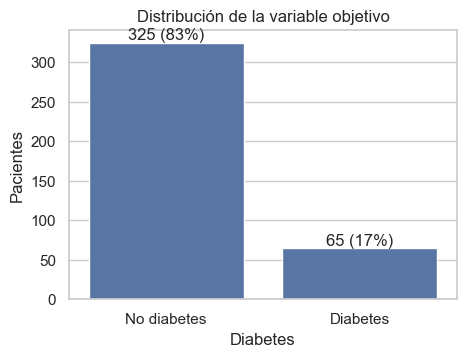

In [7]:
# Distribución de la variable objetivo
fig, ax = plt.subplots(figsize=(5, 3.5))
conteo = y.map({0: "No diabetes", 1: "Diabetes"}).value_counts()
sns.barplot(x=conteo.index, y=conteo.values, ax=ax)
for i, v in enumerate(conteo.values):
    ax.text(i, v, f"{v} ({v / len(y):.0%})", ha="center", va="bottom")
ax.set_title("Distribución de la variable objetivo"); ax.set_ylabel("Pacientes")
plt.show()

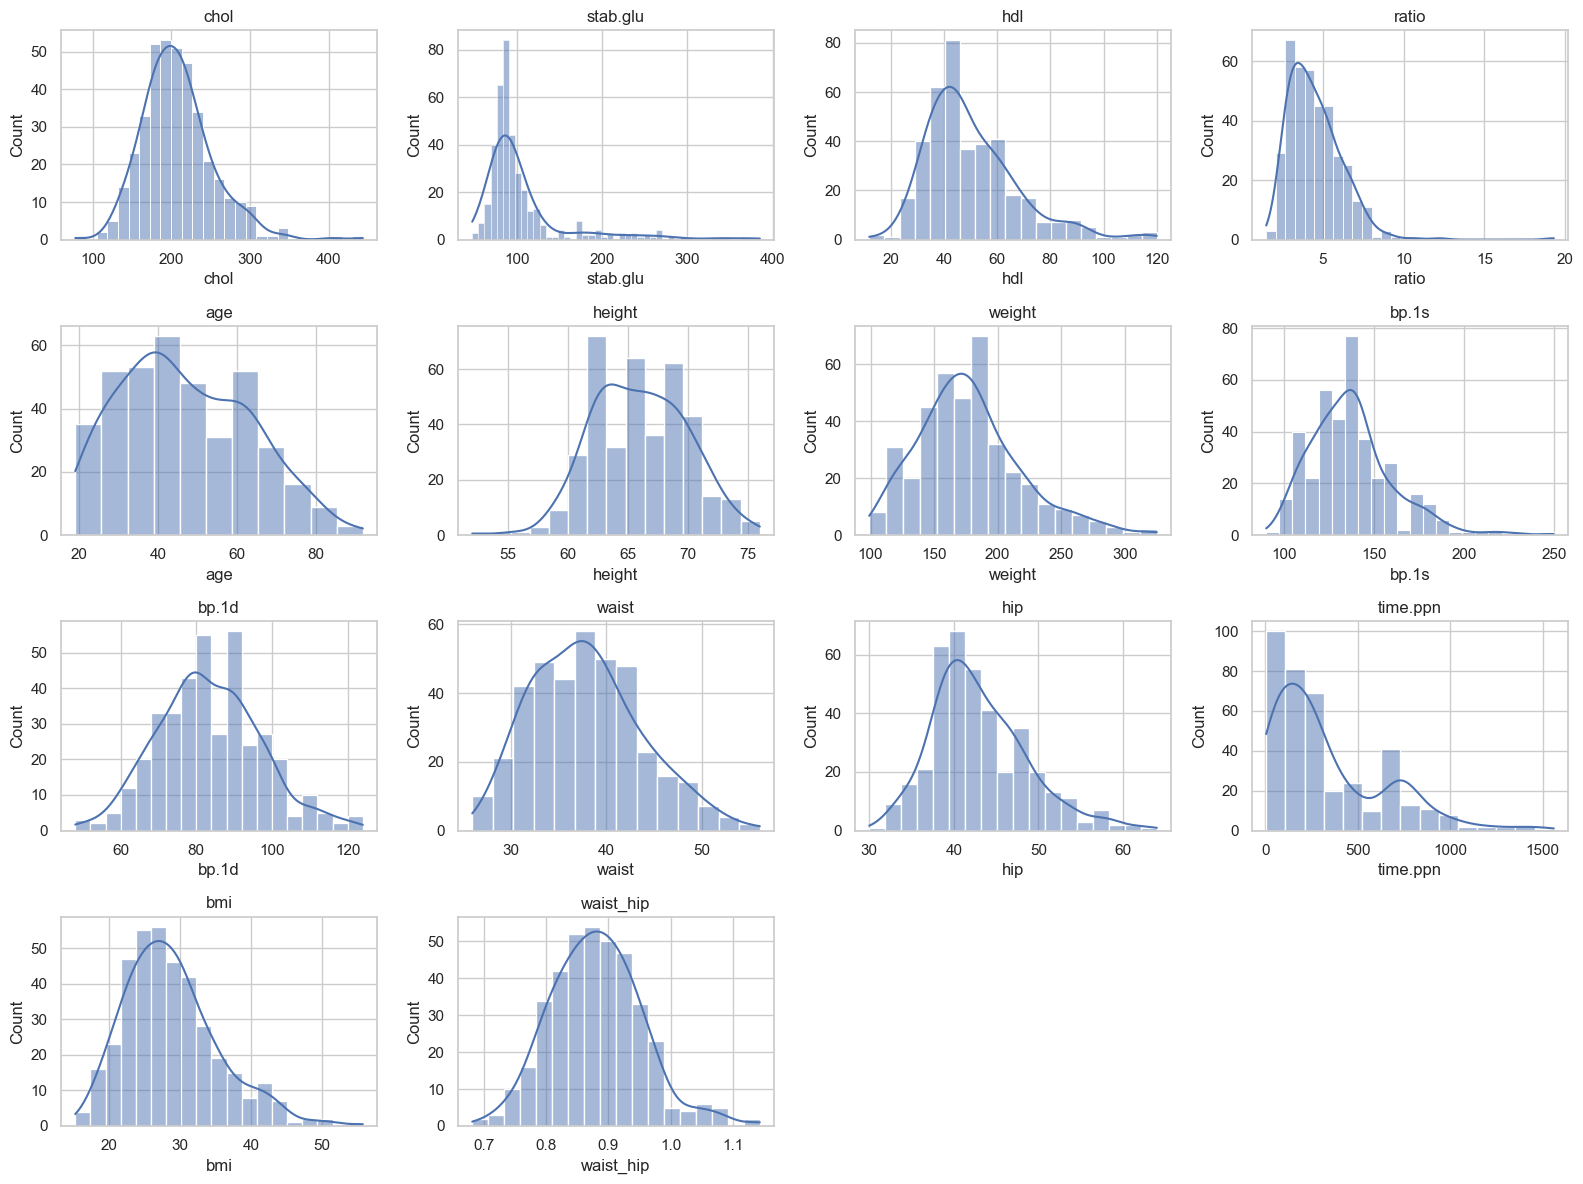

In [8]:
# Histogramas de las variables numéricas
n = len(num_cols); ncols = 4; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
for ax, c in zip(axes.ravel(), num_cols):
    sns.histplot(X[c], kde=True, ax=ax); ax.set_title(c)
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

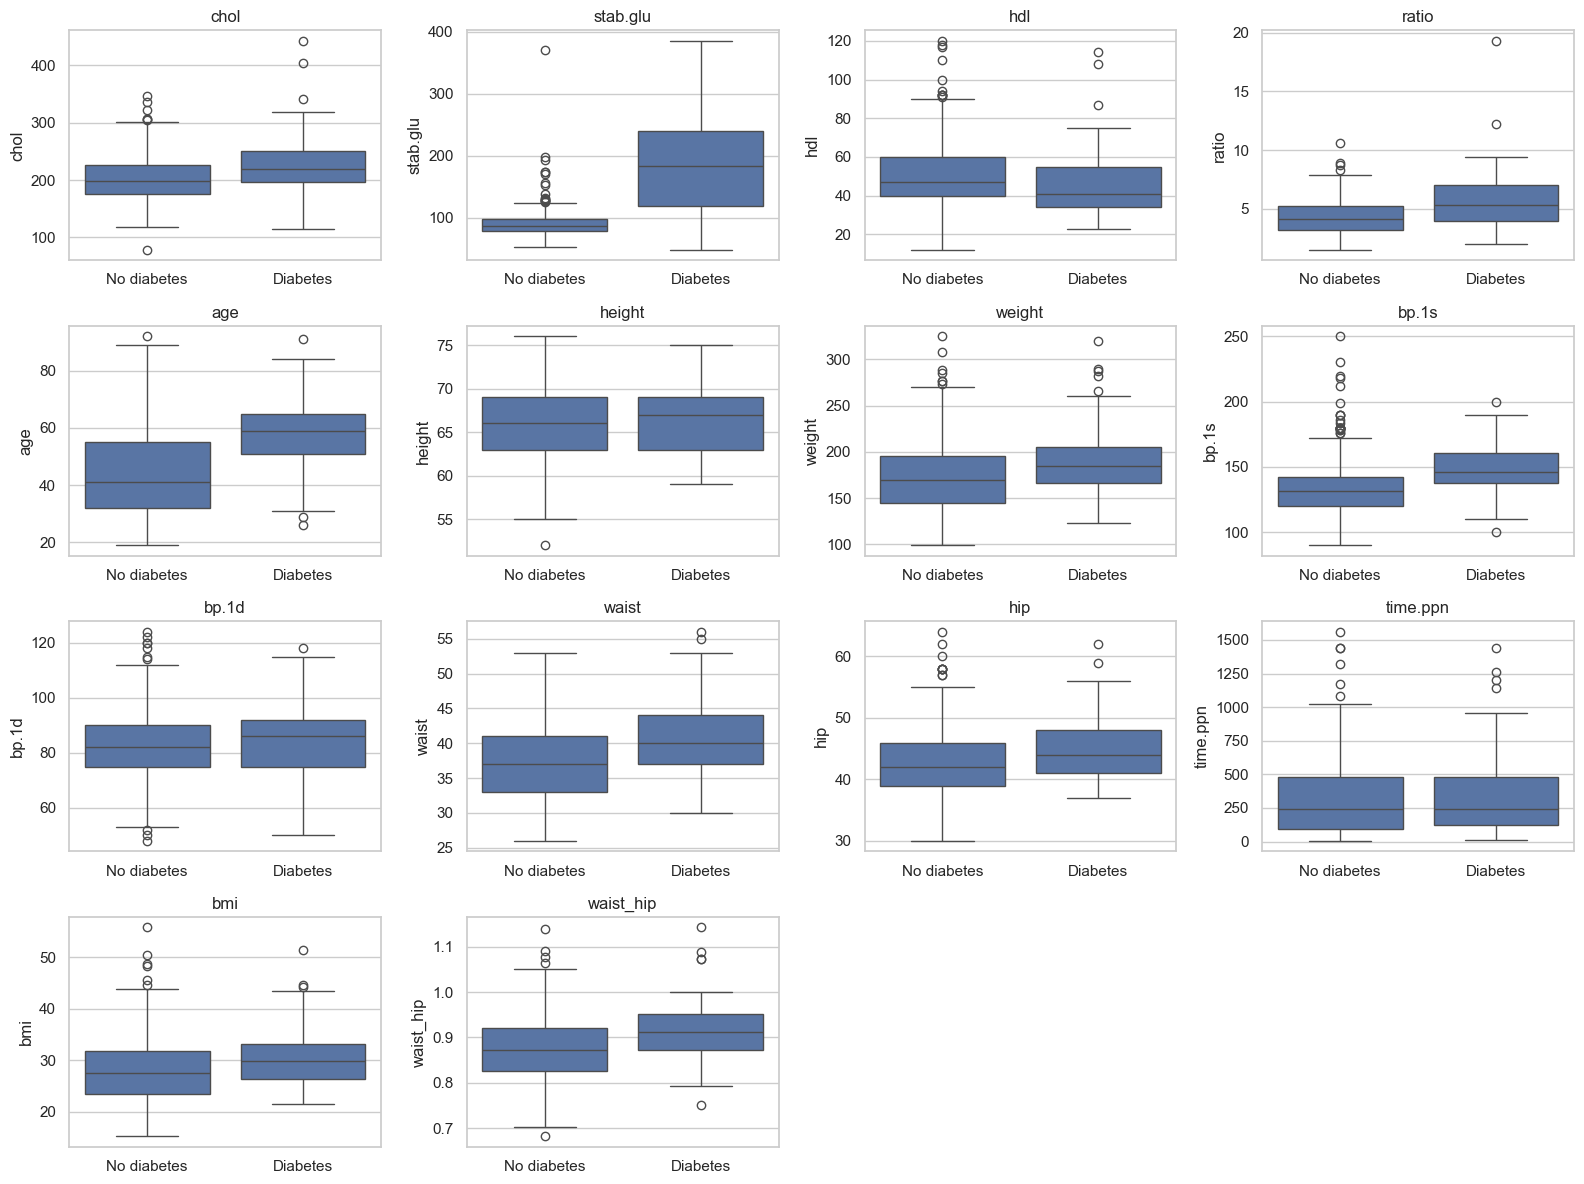

In [9]:
# Boxplots de cada variable numérica según la clase
etiqueta = y.map({0: "No diabetes", 1: "Diabetes"})
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
for ax, c in zip(axes.ravel(), num_cols):
    sns.boxplot(x=etiqueta, y=X[c], ax=ax); ax.set_title(c); ax.set_xlabel("")
for ax in axes.ravel()[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

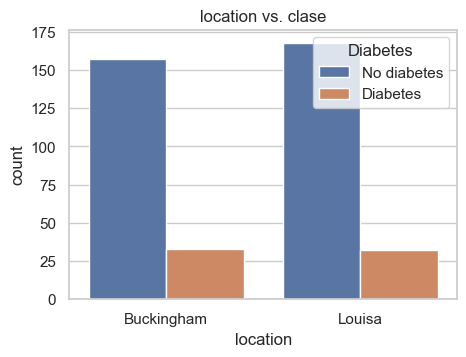

Diabetes    Diabetes  No diabetes
location                         
Buckingham     0.174        0.826
Louisa         0.160        0.840


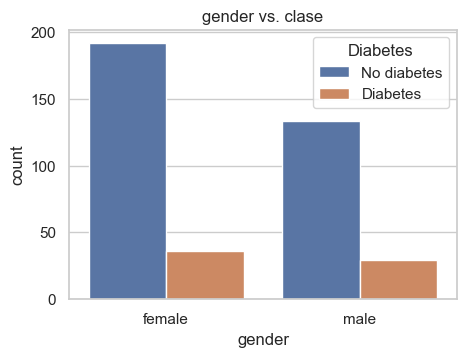

Diabetes  Diabetes  No diabetes
gender                         
female       0.158        0.842
male         0.179        0.821


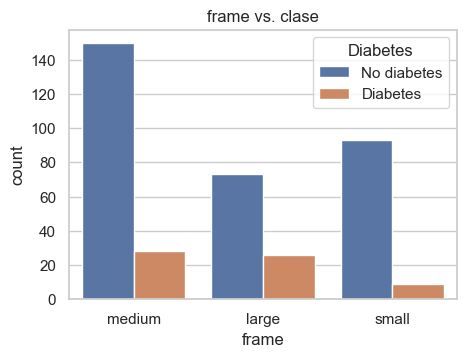

Diabetes  Diabetes  No diabetes
frame                          
large        0.263        0.737
medium       0.157        0.843
small        0.088        0.912


In [10]:
# Variables categóricas frente a la clase
for c in cat_cols:
    fig, ax = plt.subplots(figsize=(5, 3.5))
    sns.countplot(x=X[c], hue=etiqueta, ax=ax); ax.set_title(f"{c} vs. clase")
    plt.show()
    print(pd.crosstab(X[c], etiqueta, normalize="index").round(3))

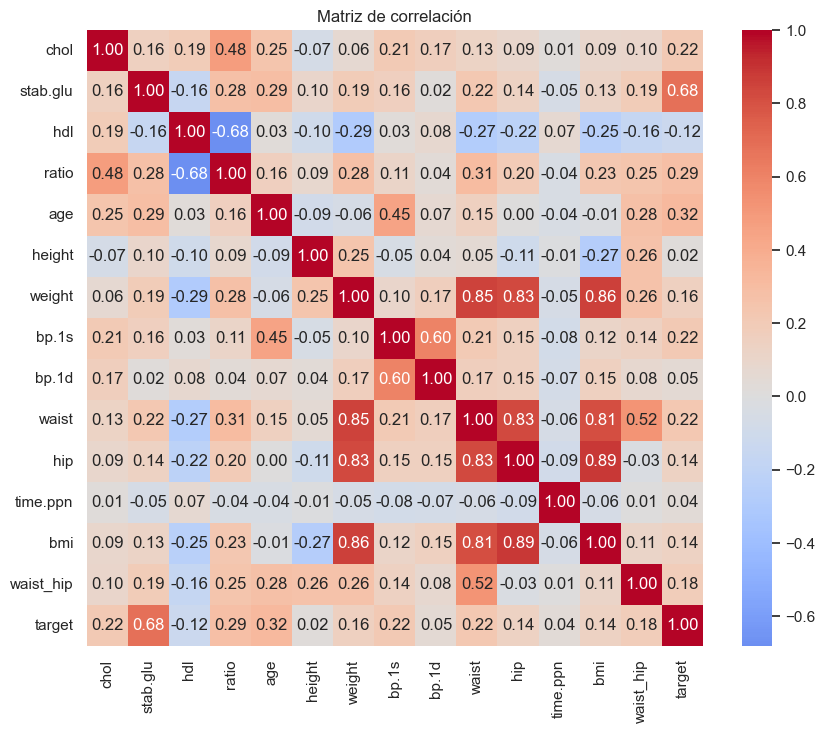

Correlación con la clase objetivo (ordenada):


stab.glu     0.685
age          0.318
ratio        0.286
waist        0.224
bp.1s        0.217
chol         0.216
waist_hip    0.185
weight       0.155
hip          0.139
bmi          0.135
hdl         -0.124
bp.1d        0.049
time.ppn     0.038
height       0.018
Name: target, dtype: float64

In [11]:
# Correlaciones entre variables numéricas y con la clase
corr = X[num_cols].assign(target=y).corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación"); plt.show()

print("Correlación con la clase objetivo (ordenada):")
corr["target"].drop("target").sort_values(key=abs, ascending=False).round(3)

### Análisis preliminar

*(Valores calculados sobre este archivo; verifícalos en las salidas de arriba.)*

- **Tamaño y etiqueta.** Tras eliminar los 13 pacientes sin `glyhb` quedan **390** registros, sin filas duplicadas. **65 son diabéticos (16.7 %)** y 325 no: un desbalance moderado. Un modelo que dijera siempre "no diabetes" tendría ≈ 83 % de accuracy, por eso la métrica principal es **ROC-AUC** y se reportan también precision, recall y F1.
- **Tipos y escalas.** Tras la limpieza hay 12 variables numéricas originales, 3 categóricas (`location`, `gender`, `frame`) y 2 derivadas (IMC y relación cintura/cadera). Las escalas son muy distintas (`time.ppn` va de 5 a 1560 min, `ratio` de 1.5 a 19.3), pero los modelos basados en árboles no necesitan estandarización; solo el Bagging con regresión logística escala los datos, dentro de su propio pipeline.
- **Valores faltantes.** `bp.2s` y `bp.2d` faltan en ≈ 65 % de los pacientes (la segunda medición de presión solo se tomó a algunos), por lo que se descartan. El resto tiene menos de 3 % de faltantes y se imputa con mediana (numéricas) o moda (categóricas) **dentro del pipeline**, para no filtrar información del fold de validación.
- **Asimetría y outliers.** `stab.glu` es la más asimétrica (asimetría ≈ 2.7, unos 50 valores atípicos por la regla del IQR, con máximos cercanos a 385), seguida de `ratio` (≈ 2.2). Estos valores extremos corresponden en gran parte a pacientes diabéticos, así que no se eliminan; además, los árboles son robustos a ellos.
- **Variables más asociadas a la clase.** `stab.glu` domina con claridad (correlación ≈ 0.69; mediana de 184 en diabéticos frente a 86 en no diabéticos). Le siguen `age` (≈ 0.32), `ratio` (≈ 0.29), `waist`, `bp.1s` y `chol` (≈ 0.22). `time.ppn`, `height`, `bp.1d` y las diferencias por `gender` o `location` aportan poca señal.
- **Multicolinealidad.** Peso, cintura, cadera e IMC están fuertemente relacionados entre sí; no afecta a los árboles, pero sí conviene tenerlo presente al interpretar la importancia de variables.

## 4. Partición de datos, validación cruzada y modelos

- Se reserva un **20 % de prueba** (estratificado) que **no se usa** en el entrenamiento ni en la selección de hiperparámetros.
- Sobre el 80 % restante se aplica **validación cruzada estratificada de 10 folds** dentro de `GridSearchCV`.
- Todo el preprocesamiento (imputación, codificación) va **dentro del `Pipeline`**, de modo que se ajusta solo con los datos de entrenamiento de cada fold.
- Métrica de selección: **ROC-AUC** (se reportan también accuracy, precision, recall y F1).
- Se incluye un **baseline** (`DummyClassifier`) como referencia mínima.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED)
print("Entrenamiento:", X_train.shape, f"({y_train.mean():.1%} diabéticos)")
print("Prueba       :", X_test.shape, f"({y_test.mean():.1%} diabéticos)")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)
scoring = {"roc_auc": "roc_auc", "accuracy": "accuracy", "precision": "precision",
           "recall": "recall", "f1": "f1"}

def make_pre(scale=False):
    pasos_num = [("imp", SimpleImputer(strategy="median"))]
    if scale:
        pasos_num.append(("sc", StandardScaler()))
    pasos_cat = [("imp", SimpleImputer(strategy="most_frequent")),
                 ("oh", OneHotEncoder(handle_unknown="ignore", drop="if_binary"))]
    return ColumnTransformer([("num", Pipeline(pasos_num), num_cols),
                              ("cat", Pipeline(pasos_cat), cat_cols)])

spw = (y_train == 0).sum() / (y_train == 1).sum()   # razón negativos/positivos (para XGBoost)
print(f"scale_pos_weight de referencia: {spw:.2f}")

Entrenamiento: (312, 17) (16.7% diabéticos)
Prueba       : (78, 17) (16.7% diabéticos)
scale_pos_weight de referencia: 5.00


### 4.1 Modelos y mallas de hiperparámetros

| Modelo | Hiperparámetros explorados |
|---|---|
| Árbol de decisión | `criterion`, `max_depth`, `min_samples_leaf`, `class_weight` |
| Bagging – árboles | `n_estimators`, `max_samples`, `max_features`, `max_depth` del árbol base |
| Bagging – regresión logística | `n_estimators`, `max_samples`, `max_features`, `C` de la regresión base |
| Random Forest | `n_estimators`, `max_depth`, `min_samples_leaf`, `max_features`, `class_weight` |
| AdaBoost | `n_estimators`, `learning_rate`, profundidad del árbol base |
| XGBoost | `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`, `scale_pos_weight` |

In [13]:
modelos = {
    "Baseline (clase mayoritaria)": (
        Pipeline([("pre", make_pre()), ("model", DummyClassifier(strategy="prior"))]),
        {}),

    "Árbol de decisión": (
        Pipeline([("pre", make_pre()), ("model", DecisionTreeClassifier(random_state=SEED))]),
        {"model__criterion": ["gini", "entropy"],
         "model__max_depth": [2, 3, 4, 5, 6, 8, None],
         "model__min_samples_leaf": [1, 3, 5, 10],
         "model__class_weight": [None, "balanced"]}),

    "Bagging (árboles)": (
        Pipeline([("pre", make_pre()),
                  ("model", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=SEED),
                                              random_state=SEED))]),
        {"model__n_estimators": [50, 100, 200],
         "model__max_samples": [0.6, 0.8, 1.0],
         "model__max_features": [0.6, 1.0],
         "model__estimator__max_depth": [3, 5, None]}),

    "Bagging (regresión logística)": (
        Pipeline([("pre", make_pre()),
                  ("model", BaggingClassifier(
                      estimator=make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
                      random_state=SEED))]),
        {"model__n_estimators": [50, 100, 200],
         "model__max_samples": [0.6, 0.8, 1.0],
         "model__max_features": [0.6, 1.0],
         "model__estimator__logisticregression__C": [0.01, 0.1, 1, 10]}),

    "Random Forest": (
        Pipeline([("pre", make_pre()), ("model", RandomForestClassifier(random_state=SEED, n_jobs=1))]),
        {"model__n_estimators": [100, 300],
         "model__max_depth": [3, 5, None],
         "model__min_samples_leaf": [1, 3, 5],
         "model__max_features": ["sqrt", 0.5],
         "model__class_weight": [None, "balanced_subsample"]}),

    "AdaBoost": (
        Pipeline([("pre", make_pre()),
                  ("model", AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                               random_state=SEED))]),
        {"model__n_estimators": [50, 100, 200],
         "model__learning_rate": [0.01, 0.1, 0.5, 1.0],
         "model__estimator": [DecisionTreeClassifier(max_depth=d, random_state=SEED) for d in (1, 2, 3)]}),

    "XGBoost": (
        Pipeline([("pre", make_pre()),
                  ("model", XGBClassifier(eval_metric="logloss", tree_method="hist",
                                          random_state=SEED, n_jobs=1))]),
        {"model__n_estimators": [100, 300],
         "model__max_depth": [2, 3, 5],
         "model__learning_rate": [0.03, 0.1, 0.3],
         "model__subsample": [0.8, 1.0],
         "model__colsample_bytree": [0.8, 1.0],
         "model__scale_pos_weight": [1, spw]}),
}
for nombre, (_, malla) in modelos.items():
    n_comb = int(np.prod([len(v) for v in malla.values()])) if malla else 1
    print(f"{nombre:32s} {n_comb:4d} combinaciones x 10 folds = {n_comb * 10} ajustes")

Baseline (clase mayoritaria)        1 combinaciones x 10 folds = 10 ajustes
Árbol de decisión                 112 combinaciones x 10 folds = 1120 ajustes
Bagging (árboles)                  54 combinaciones x 10 folds = 540 ajustes
Bagging (regresión logística)      72 combinaciones x 10 folds = 720 ajustes
Random Forest                      72 combinaciones x 10 folds = 720 ajustes
AdaBoost                           36 combinaciones x 10 folds = 360 ajustes
XGBoost                           144 combinaciones x 10 folds = 1440 ajustes


## 5. Entrenamiento con validación cruzada de 10 folds

In [14]:
resultados = {}
for nombre, (pipe, malla) in modelos.items():
    t0 = time.time()
    gs = GridSearchCV(pipe, malla, cv=cv, scoring=scoring, refit="roc_auc",
                      n_jobs=-1, error_score="raise")
    gs.fit(X_train, y_train)
    resultados[nombre] = gs
    print(f"{nombre:32s} CV ROC-AUC = {gs.best_score_:.3f}   ({time.time() - t0:.0f} s)")

Baseline (clase mayoritaria)     CV ROC-AUC = 0.500   (5 s)
Árbol de decisión                CV ROC-AUC = 0.921   (11 s)
Bagging (árboles)                CV ROC-AUC = 0.934   (29 s)
Bagging (regresión logística)    CV ROC-AUC = 0.931   (65 s)
Random Forest                    CV ROC-AUC = 0.949   (37 s)
AdaBoost                         CV ROC-AUC = 0.946   (16 s)
XGBoost                          CV ROC-AUC = 0.943   (19 s)


## 6. Comparación de modelos

In [15]:
filas = []
for nombre, gs in resultados.items():
    r, i = gs.cv_results_, gs.best_index_
    proba = gs.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    filas.append({
        "Modelo": nombre,
        "CV ROC-AUC": r["mean_test_roc_auc"][i], "± std": r["std_test_roc_auc"][i],
        "CV Accuracy": r["mean_test_accuracy"][i], "CV Precision": r["mean_test_precision"][i],
        "CV Recall": r["mean_test_recall"][i], "CV F1": r["mean_test_f1"][i],
        "Test ROC-AUC": roc_auc_score(y_test, proba), "Test Accuracy": accuracy_score(y_test, pred),
        "Test Precision": precision_score(y_test, pred, zero_division=0),
        "Test Recall": recall_score(y_test, pred), "Test F1": f1_score(y_test, pred),
    })
tabla = pd.DataFrame(filas).set_index("Modelo").sort_values("CV ROC-AUC", ascending=False)
tabla.round(3)

,CV ROC-AUC,± std,CV Accuracy,CV Precision,CV Recall,CV F1,Test ROC-AUC,Test Accuracy,Test Precision,Test Recall,Test F1
Modelo,,,,,,,,,,,
Random Forest,0.949,0.055,0.904,0.742,0.700,0.708,0.964,0.949,0.800,0.923,0.857
AdaBoost,0.946,0.069,0.914,0.852,0.600,0.689,0.961,0.910,0.800,0.615,0.696
XGBoost,0.943,0.066,0.895,0.656,0.817,0.721,0.963,0.910,0.667,0.923,0.774
Bagging (árboles),0.934,0.064,0.920,0.868,0.620,0.713,0.934,0.897,0.778,0.538,0.636
Bagging (regresión logística),0.931,0.081,0.885,0.875,0.347,0.480,0.918,0.872,0.800,0.308,0.444
Árbol de decisión,0.921,0.095,0.920,0.837,0.660,0.729,0.801,0.910,0.800,0.615,0.696
Baseline (clase mayoritaria),0.500,0.000,0.833,0.000,0.000,0.000,0.500,0.833,0.000,0.000,0.000


In [16]:
# Mejores hiperparámetros por modelo
for nombre, gs in resultados.items():
    print(f"\n{nombre}")
    for k, v in gs.best_params_.items():
        print(f"   {k.replace('model__', '')}: {v}")


Baseline (clase mayoritaria)

Árbol de decisión
   class_weight: None
   criterion: entropy
   max_depth: 2
   min_samples_leaf: 10

Bagging (árboles)
   estimator__max_depth: None
   max_features: 0.6
   max_samples: 0.6
   n_estimators: 50

Bagging (regresión logística)
   estimator__logisticregression__C: 0.1
   max_features: 0.6
   max_samples: 0.6
   n_estimators: 50

Random Forest
   class_weight: balanced_subsample
   max_depth: 5
   max_features: 0.5
   min_samples_leaf: 3
   n_estimators: 300

AdaBoost
   estimator: DecisionTreeClassifier(max_depth=2, random_state=42)
   learning_rate: 0.1
   n_estimators: 50

XGBoost
   colsample_bytree: 1.0
   learning_rate: 0.03
   max_depth: 2
   n_estimators: 100
   scale_pos_weight: 5.0
   subsample: 0.8


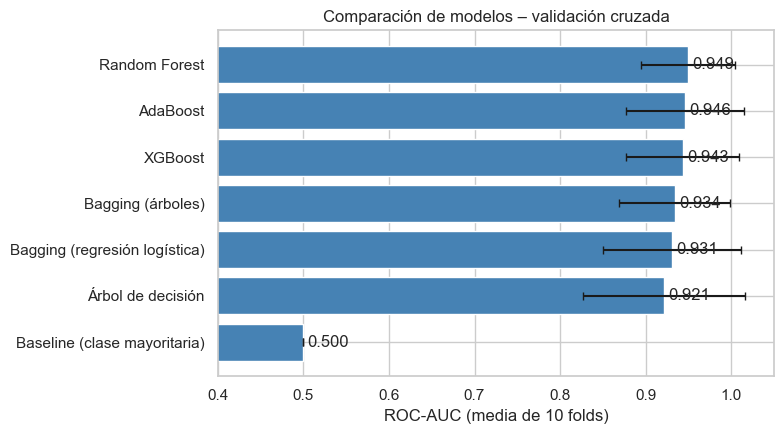

In [17]:
# Comparación visual (ROC-AUC en validación cruzada, con desviación estándar entre folds)
t = tabla.sort_values("CV ROC-AUC")
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(t.index, t["CV ROC-AUC"], xerr=t["± std"], color="steelblue", capsize=3)
for i, v in enumerate(t["CV ROC-AUC"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
ax.set_xlim(0.4, 1.05); ax.set_xlabel("ROC-AUC (media de 10 folds)")
ax.set_title("Comparación de modelos – validación cruzada")
plt.tight_layout()
fig.savefig(os.path.join(IMAGES_DIR, "comparacion_modelos.png"), dpi=150, bbox_inches="tight")
plt.show()

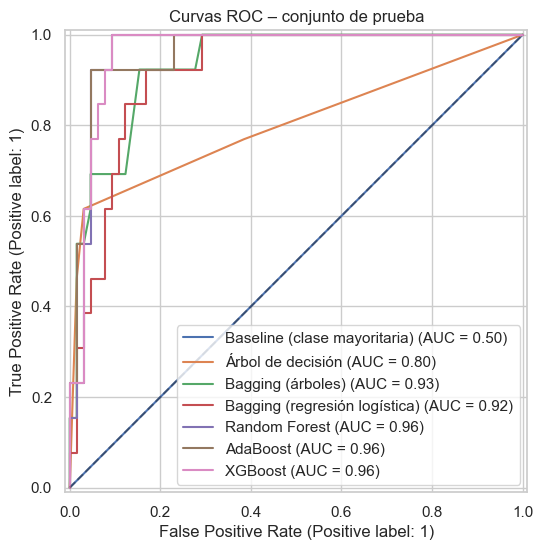

In [18]:
# Curvas ROC de todos los modelos sobre el conjunto de prueba
fig, ax = plt.subplots(figsize=(7, 6))
for nombre, gs in resultados.items():
    RocCurveDisplay.from_predictions(y_test, gs.predict_proba(X_test)[:, 1], name=nombre, ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4); ax.set_title("Curvas ROC – conjunto de prueba")
fig.savefig(os.path.join(IMAGES_DIR, "curvas_roc.png"), dpi=150, bbox_inches="tight")
plt.show()

## 7. Mejor modelo

El mejor modelo se elige por el **ROC-AUC promedio en validación cruzada** (no por el conjunto de prueba, para no "sobreajustar" la elección al test). El baseline se excluye de la selección.

Mejor modelo: Random Forest
Hiperparámetros: {'model__class_weight': 'balanced_subsample', 'model__max_depth': 5, 'model__max_features': 0.5, 'model__min_samples_leaf': 3, 'model__n_estimators': 300}

Desempeño en el conjunto de prueba (umbral 0.5):
              precision    recall  f1-score   support

 No diabetes       0.98      0.95      0.97        65
    Diabetes       0.80      0.92      0.86        13

    accuracy                           0.95        78
   macro avg       0.89      0.94      0.91        78
weighted avg       0.95      0.95      0.95        78



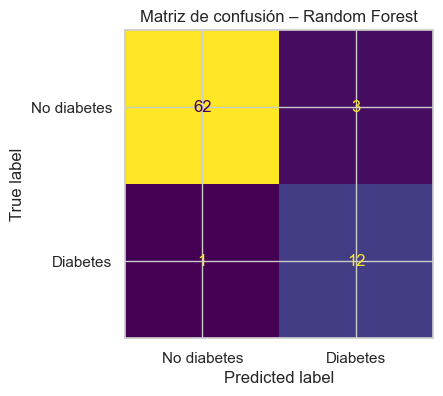

In [19]:
mejor_nombre = tabla.drop(index="Baseline (clase mayoritaria)")["CV ROC-AUC"].idxmax()
mejor = resultados[mejor_nombre].best_estimator_
print("Mejor modelo:", mejor_nombre)
print("Hiperparámetros:", resultados[mejor_nombre].best_params_)

proba = mejor.predict_proba(X_test)[:, 1]
pred = (proba >= 0.5).astype(int)
print("\nDesempeño en el conjunto de prueba (umbral 0.5):")
print(classification_report(y_test, pred, target_names=["No diabetes", "Diabetes"], zero_division=0))

fig, ax = plt.subplots(figsize=(4.5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred), display_labels=["No diabetes", "Diabetes"]).plot(ax=ax, colorbar=False)
ax.set_title(f"Matriz de confusión – {mejor_nombre}")
fig.savefig(os.path.join(IMAGES_DIR, "matriz_confusion.png"), dpi=150, bbox_inches="tight")
plt.show()

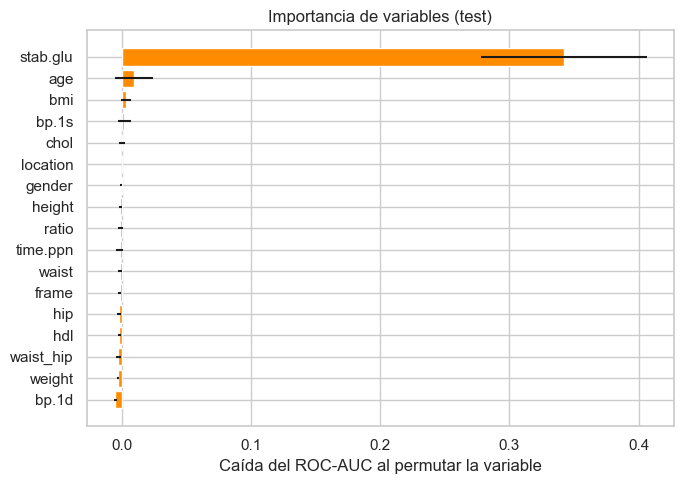

In [20]:
# Importancia de variables por permutación (funciona con cualquier modelo)
pi = permutation_importance(mejor, X_test, y_test, scoring="roc_auc", n_repeats=30, random_state=SEED)
imp = pd.Series(pi.importances_mean, index=X_test.columns).sort_values()
fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp.index, imp.values, xerr=pd.Series(pi.importances_std, index=X_test.columns)[imp.index], color="darkorange")
ax.set_xlabel("Caída del ROC-AUC al permutar la variable"); ax.set_title("Importancia de variables (test)")
plt.tight_layout()
fig.savefig(os.path.join(IMAGES_DIR, "importancia_variables.png"), dpi=150, bbox_inches="tight")
plt.show()

## 8. Guardar el mejor modelo con `joblib`

In [21]:
MODEL_PATH = os.path.join(MODEL_DIR, "mejor_modelo.joblib")
joblib.dump(mejor, MODEL_PATH)          # guarda el Pipeline completo (preprocesamiento + modelo)
print("Modelo guardado en:", MODEL_PATH)

# Verificación: cargar y predecir
modelo_cargado = joblib.load(MODEL_PATH)
ejemplo = X_test.head(5)
salida = pd.DataFrame({"prob. diabetes": modelo_cargado.predict_proba(ejemplo)[:, 1].round(3),
                       "predicción": modelo_cargado.predict(ejemplo),
                       "real": y_test.head(5).values}, index=ejemplo.index)
salida

Modelo guardado en: models\mejor_modelo.joblib


,prob. diabetes,predicción,real
133,0.801,1,1
399,0.062,0,0
389,0.062,0,0
318,0.000,0,0
136,0.212,0,0


## 9. Conclusiones

> **Completar con los resultados reales.** Sugerencia de estructura:
>
> 1. **Mejor modelo** y su ROC-AUC (CV y test), con sus hiperparámetros.
> 2. **Comparación:** ¿los métodos de ensamble mejoraron al árbol de decisión individual? ¿por cuánto frente al baseline?
> 3. **Sensibilidad vs. precisión:** en un tamizaje médico suele importar más no dejar pacientes diabéticos sin detectar (recall alto); comentar qué tan bien lo logra el modelo y qué pasaría al bajar el umbral de 0.5.
> 4. **Variables más importantes** y si coinciden con el conocimiento clínico (glucosa, relación colesterol/HDL, edad, medidas de cintura/IMC).
> 5. **Limitaciones:** dataset pequeño (≈ 390 pacientes; el conjunto de prueba tiene solo unos 10–15 positivos, así que las métricas de test son muy variables), población específica (no generalizable a otras poblaciones) y desbalance de clases.
> 6. **Trabajo futuro:** ajuste del umbral, calibración de probabilidades, más datos, validación externa.